# T7 — Definición y Ejecución de la Evaluación con Benchmark

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral  
para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período:** 16/02/2026 – 01/03/2026

---

## Objetivo de esta etapa

Contrastar formalmente el **sistema propuesto** (motor híbrido SBERT + TF-IDF)  
contra cuatro benchmarks de complejidad creciente, tal como establece el plan de trabajo:  
*"Evaluar el rendimiento del Motor de Matching mediante una métrica de precisión/similitud  
y contrastarlo con un benchmark simple de keyword matching."*

## Sistemas evaluados

| ID | Sistema | Descripción |
|---|---|---|
| B0 | **Keyword Match** | Baseline más simple: coincidencia literal del keyword del CV en el texto de la oferta |
| B1 | **Jaccard BoW** | Similitud de Jaccard sobre bolsa de palabras (sin ponderación) |
| B2 | **TF-IDF** | Vectorización clásica con similitud coseno (T4) |
| B3 | **SBERT puro** | Embeddings multilingüe sin ponderación TF-IDF (T5) — aísla la contribución semántica |
| S | **SBERT Híbrido** | Sistema propuesto: embeddings + TF-IDF ponderados 70/30 (T5+T6) |

## Protocolo de evaluación

- **Corpus:** `ofertas_preprocesadas.csv` (1 279 ofertas con descripción útil)
- **Query:** CV del candidato (Carlos A. Cicconi)
- **Ground truth proxy:** dado que no existe juicio humano de relevancia,  
  se define relevancia con **dos criterios complementarios**:
  1. *Binario:* `similitud_embed ≥ percentil 75` del corpus → relevante / no relevante
  2. *Graduado:* `similitud_embed` como score continuo de relevancia
- **Métricas:** Precision@K, nDCG@K, MRR, Hit Rate@K, Tiempo de cómputo

## Inputs
- `ofertas_preprocesadas.csv` — corpus con `similitud_tfidf` y `similitud_embed`
- `ranking_final_combinado.csv` — ranking del sistema propuesto (T6)
- `cv_texto_limpio.txt` — tokens del CV para Jaccard
- `CarlosA_Cicconi_CV.pdf` — texto natural del CV para Keyword Match

## Outputs
- `benchmark_resultados.csv` — scores de los 4 sistemas para cada oferta
- `benchmark_metricas.json` — tabla comparativa de métricas
- `tabla_benchmark.md` — tabla lista para copiar en la tesis
- `fig_t7_*.png` — gráficos comparativos


## 0. Configuración del entorno

In [1]:
import re
import json
import time
import zipfile
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

print('✅ Entorno configurado')
print(f'   pandas {pd.__version__}  |  numpy {np.__version__}')

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_NB   = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
_ROOT = _NB.parent if _NB.name != 'notebooks' else _NB.parent
if _ROOT.name == 'notebooks': _ROOT = _ROOT.parent
_PROC    = _ROOT / 'data'    / 'processed'
_CVDIR   = _ROOT / 'data'    / 'cvs'
_RANKINGS= _ROOT / 'outputs' / 'rankings'
_REPORTS = _ROOT / 'outputs' / 'reports'
_FIGS    = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_RANKINGS.mkdir(parents=True, exist_ok=True)
_REPORTS.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT     : {_ROOT}')
print(f'PROC     : {_PROC}')
print(f'CVDIR    : {_CVDIR}')
print(f'RANKINGS : {_RANKINGS}')
print(f'REPORTS  : {_REPORTS}')
print(f'FIGS     : {_FIGS}')


✅ Entorno configurado
   pandas 2.2.3  |  numpy 2.2.4
ROOT     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD
PROC     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/processed
CVDIR    : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/cvs
RANKINGS : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/rankings
REPORTS  : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/reports
FIGS     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/figures


## 1. Carga de datos

In [2]:
# ── Corpus ───────────────────────────────────────────────────────────────────
if (_PROC / 'ofertas_preprocesadas.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_preprocesadas.csv', low_memory=False)
    print(f'✅ ofertas_preprocesadas.csv — {len(df):,} filas x {df.shape[1]} cols')
elif (_PROC / 'ofertas_con_descripcion.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_con_descripcion.csv', low_memory=False)
    print(f'✅ ofertas_con_descripcion.csv — {len(df):,} filas (fallback T3)')
else:
    raise FileNotFoundError(f'No se encontró el corpus en {_PROC}.')

# Filtrar solo documentos con texto útil
df = df[df['descripcion'].fillna('').str.len() > 50].copy().reset_index(drop=True)
print(f'   Documentos válidos: {len(df):,}')

# Verificar disponibilidad de similitudes
tiene_embed = 'similitud_embed' in df.columns and df['similitud_embed'].notna().any()
tiene_tfidf = 'similitud_tfidf' in df.columns and df['similitud_tfidf'].notna().any()
print(f'   similitud_embed: {"✅" if tiene_embed else "❌"}  |  similitud_tfidf: {"✅" if tiene_tfidf else "❌"}')


✅ ofertas_preprocesadas.csv — 2,476 filas x 18 cols
   Documentos válidos: 2,476
   similitud_embed: ❌  |  similitud_tfidf: ✅


In [3]:
# ── Ranking del sistema propuesto (T6) ───────────────────────────────────────
if (_RANKINGS / 'ranking_final_combinado.csv').exists():
    df_sistema = pd.read_csv(_RANKINGS / 'ranking_final_combinado.csv')
    print(f'✅ ranking_final_combinado.csv — {len(df_sistema):,} filas')
    # Incorporar score_final al corpus si no está
    if 'score_final' not in df.columns and 'id_consolidado' in df_sistema.columns:
        df = df.merge(df_sistema[['id_consolidado','score_final']],
                      on='id_consolidado', how='left')
else:
    df_sistema = None
    print('ℹ️  ranking_final_combinado.csv no encontrado — se recalculará el score final')


✅ ranking_final_combinado.csv — 2,476 filas


In [4]:
# ── CV del candidato ─────────────────────────────────────────────────────────
def leer_cv_pdf(ruta: Path) -> str:
    try:
        import pdfplumber
        with pdfplumber.open(str(ruta)) as pdf:
            return chr(10).join(p.extract_text() or '' for p in pdf.pages).strip()
    except Exception:
        pass
    try:
        from pypdf import PdfReader
        r = PdfReader(str(ruta))
        return chr(10).join(p.extract_text() or '' for p in r.pages).strip()
    except Exception:
        return ''

# Texto natural (para Keyword Match y TF-IDF)
if (_CVDIR / 'CarlosA.Cicconi_CV.pdf').exists():
    cv_texto_natural = leer_cv_pdf(_CVDIR / 'CarlosA.Cicconi_CV.pdf')
    print(f'✅ CV PDF — {len(cv_texto_natural):,} chars')
else:
    cv_texto_natural = ''
    print('⚠️  CarlosA_Cicconi_CV.pdf no encontrado')

# Tokens lematizados (para Jaccard)
if (_PROC / 'cv_texto_limpio.txt').exists():
    cv_tokens_str = (_PROC / 'cv_texto_limpio.txt').read_text(encoding='utf-8')
    cv_tokens_set = set(cv_tokens_str.lower().split())
    print(f'✅ cv_texto_limpio.txt — {len(cv_tokens_set):,} tokens únicos')
else:
    cv_tokens_str = re.sub(r'[^\w\s]', ' ', cv_texto_natural.lower())
    cv_tokens_set = set(cv_tokens_str.split())
    print(f'ℹ️  Tokens del CV generados desde PDF — {len(cv_tokens_set):,} únicos')

print()
print('Muestra de tokens del CV:', list(cv_tokens_set)[:15])


✅ CV PDF — 3,240 chars
✅ cv_texto_limpio.txt — 167 tokens únicos

Muestra de tokens del CV: ['costo', 'santa', 'productividad', 'activación', 'arroyos', 'ternium', 'sap', 'contrato', 'tenaris', 'anual', 'primo', 'gerente', 'planificación', 'planta', 'liderazgo']


## 2. Definición del ground truth (proxy de relevancia)

Sin juicio humano de relevancia, definimos dos niveles de ground truth:  

**Nivel 1 — Binario:** una oferta es *relevante* si su `similitud_embed`  
supera el percentil 75 del corpus. Esto selecciona el 25% de ofertas más  
similares semánticamente al CV, según el mejor modelo disponible (SBERT).  

**Nivel 2 — Graduado (3 niveles):**
- **Alta relevancia** (sim_embed ≥ p75): recomendación fuerte
- **Relevancia media** (p50 ≤ sim_embed < p75): recomendación moderada
- **Baja relevancia** (sim_embed < p50): no recomendado

> **Nota metodológica:** usar SBERT como proxy es un estándar en la  
> literatura cuando no hay anotadores humanos. Implica que el benchmark  
> evalúa qué tan bien cada sistema *aproxima* el ranking de SBERT, lo que  
> favorece al sistema híbrido por diseño. Esta limitación se documenta  
> explícitamente en la tesis y se mitiga con el análisis cualitativo de T6.


In [5]:
# ── Definir ground truth ─────────────────────────────────────────────────────
if tiene_embed:
    sim_ref = df['similitud_embed'].fillna(0)
else:
    # Fallback: usar TF-IDF si no hay embeddings
    sim_ref = df['similitud_tfidf'].fillna(0)
    print('⚠️  Usando TF-IDF como referencia (embeddings no disponibles)')

P75 = sim_ref.quantile(0.75)
P50 = sim_ref.quantile(0.50)

df['relevancia_binaria']  = (sim_ref >= P75).astype(int)
df['relevancia_graduada'] = pd.cut(
    sim_ref,
    bins=[-np.inf, P50, P75, np.inf],
    labels=[0, 1, 2]   # 0=baja, 1=media, 2=alta
).astype(float)

n_rel = df['relevancia_binaria'].sum()
print(f'Ground truth definido:')
print(f'  Umbral p75 (θ)       : {P75:.4f}')
print(f'  Umbral p50           : {P50:.4f}')
print(f'  Ofertas relevantes   : {n_rel:,} ({n_rel/len(df)*100:.1f}%)')
print(f'  Ofertas no relevantes: {len(df)-n_rel:,}')
print()

# Distribución de relevancia por keyword
rel_kw = df.groupby('keyword')['relevancia_binaria'].mean().sort_values(ascending=False)
print('% de ofertas relevantes por keyword:')
for kw, val in rel_kw.items():
    bar = '█' * int(val * 20)
    print(f'  {kw:<35} {val*100:>5.1f}%  {bar}')


⚠️  Usando TF-IDF como referencia (embeddings no disponibles)
Ground truth definido:
  Umbral p75 (θ)       : 0.0543
  Umbral p50           : 0.0327
  Ofertas relevantes   : 619 (25.0%)
  Ofertas no relevantes: 1,857

% de ofertas relevantes por keyword:
  Ingeniero de Datos                   61.7%  ████████████
  Data Analyst                         39.2%  ███████
  Desarrollador Full Stack             30.1%  ██████
  NLP Engineer                         24.4%  ████
  Machine Learning                     23.5%  ████
  Machine Learning Engineer            21.9%  ████
  Software Engineer                    20.5%  ████
  Data Engineer                        18.2%  ███
  Data Scientist                       18.1%  ███
  Backend                              17.4%  ███
  Python Developer                     12.8%  ██
  Full Stack                           11.1%  ██
  Desarrollador Backend                 5.6%  █


## 3. Implementación de los benchmarks

### B0 — Keyword Match (baseline más simple)

Verifica si alguna de las palabras clave del CV aparece literalmente  
en el título o descripción de cada oferta. El score es la proporción  
de keywords del CV encontradas en el texto de la oferta.  
Es el equivalente digital de buscar manualmente por palabras clave.


In [6]:
# ── B0: Keyword Match ────────────────────────────────────────────────────────
# Keywords del CV extraídas del keywords.json (generado en T2)
# Complementado con términos clave del cv_texto_limpio

KW_CV = []
if (_CVDIR / 'keywords.json').exists():
    with open(_CVDIR / 'keywords.json') as f:
        kw_data = json.load(f)
    KW_CV = [k.lower() for k in kw_data.get('keywords', [])]
    print(f'Keywords del CV desde keywords.json: {len(KW_CV)}')

# Agregar términos del texto natural del CV
kw_extra = [
    'data scientist', 'python', 'power bi', 'machine learning',
    'control de gestion', 'supply chain', 'compras', 'procurement',
    'ingeniero industrial', 'sap', 'excel', 'finanzas', 'presupuesto',
    'mejora continua', 'continuous improvement', 'lean', 'kpi',
    'data analyst', 'business intelligence', 'bi', 'analytics',
]
KW_CV = list(set(KW_CV + kw_extra))
print(f'Total keywords del CV (con extras): {len(KW_CV)}')
print('Muestra:', KW_CV[:8])

def score_keyword_match(texto: str, keywords: list) -> float:
    if not texto:
        return 0.0
    texto_lower = str(texto).lower()
    hits = sum(1 for kw in keywords if kw in texto_lower)
    return hits / len(keywords) if keywords else 0.0

t0 = time.time()
texto_oferta = (df['titulo'].fillna('') + ' ' + df['descripcion'].fillna(''))
df['score_B0'] = texto_oferta.apply(lambda t: score_keyword_match(t, KW_CV))
tiempo_B0 = (time.time() - t0) * 1000

print(f'\n✅ B0 Keyword Match calculado en {tiempo_B0:.0f} ms')
print(f'   Score promedio: {df["score_B0"].mean():.4f}  |  máx: {df["score_B0"].max():.4f}')
print(f'   Ofertas con score > 0: {(df["score_B0"] > 0).sum():,}')


Keywords del CV desde keywords.json: 11
Total keywords del CV (con extras): 28
Muestra: ['continuous improvement', 'excel / vba', 'sap', 'compras', 'data analyst', 'python', 'procurement', 'supply chain']



✅ B0 Keyword Match calculado en 194 ms
   Score promedio: 0.0955  |  máx: 0.3571
   Ofertas con score > 0: 2,414


### B1 — Jaccard sobre Bag of Words

Mide la similitud como la intersección dividida la unión de los conjuntos  
de palabras del CV y de cada oferta. Captura overlap léxico sin ponderación,  
lo que lo hace más robusto que Keyword Match pero aún sin semántica.


In [7]:
# ── B1: Jaccard BoW ──────────────────────────────────────────────────────────
def tokenizar(texto: str) -> set:
    if not texto:
        return set()
    tokens = re.sub(r'[^\w\s]', ' ', str(texto).lower()).split()
    # Eliminar tokens muy cortos
    return {t for t in tokens if len(t) > 2}

def jaccard(set_a: set, set_b: set) -> float:
    if not set_a or not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

t0 = time.time()
# Usar tokens del cv_texto_limpio (ya preprocesados) para Jaccard
df['score_B1'] = texto_oferta.apply(
    lambda t: jaccard(cv_tokens_set, tokenizar(t))
)
tiempo_B1 = (time.time() - t0) * 1000

print(f'✅ B1 Jaccard BoW calculado en {tiempo_B1:.0f} ms')
print(f'   Score promedio: {df["score_B1"].mean():.4f}  |  máx: {df["score_B1"].max():.4f}')


✅ B1 Jaccard BoW calculado en 352 ms
   Score promedio: 0.0337  |  máx: 0.0818


### B2 — TF-IDF (baseline estándar de recuperación de información)

Vectorización con TF-IDF y similitud coseno, ya calculada en T4.  
Si `similitud_tfidf` no está en el corpus, se recalcula aquí desde cero  
con los mismos hiperparámetros usados en T4 para garantizar comparabilidad.


In [8]:
# ── B2: TF-IDF ───────────────────────────────────────────────────────────────
if tiene_tfidf:
    df['score_B2'] = df['similitud_tfidf'].fillna(0)
    tiempo_B2 = 0  # ya calculado en T4
    print(f'✅ B2 TF-IDF: similitud_tfidf cargada desde corpus (calculada en T4)')
else:
    print('ℹ️  Recalculando TF-IDF desde cero...')
    t0 = time.time()

    col_texto = 'texto_procesado' if 'texto_procesado' in df.columns else 'descripcion'
    corpus = df[col_texto].fillna('').tolist()

    # CV: usar texto procesado si está disponible
    if (_PROC / 'cv_texto_limpio.txt').exists():
        cv_tfidf_text = cv_tokens_str
    else:
        cv_tfidf_text = re.sub(r'[^\w\s]', ' ', cv_texto_natural.lower())

    vectorizer = TfidfVectorizer(
        ngram_range=(1,2), min_df=2, max_df=0.90,
        max_features=15_000, sublinear_tf=True, norm='l2'
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    cv_vec       = vectorizer.transform([cv_tfidf_text])
    sims         = cosine_similarity(cv_vec, tfidf_matrix).flatten()
    df['score_B2'] = sims
    tiempo_B2 = (time.time() - t0) * 1000
    print(f'✅ B2 TF-IDF recalculado en {tiempo_B2:.0f} ms')

print(f'   Score promedio: {df["score_B2"].mean():.4f}  |  máx: {df["score_B2"].max():.4f}')


✅ B2 TF-IDF: similitud_tfidf cargada desde corpus (calculada en T4)
   Score promedio: 0.0383  |  máx: 0.1868


### B3 — SBERT puro (sin ponderación TF-IDF)

El modelo de embeddings aplicado de forma independiente, sin combinar con TF-IDF.  
Su inclusión como sistema separado permite aislar la contribución de cada componente:  

- Si **SBERT puro ≈ SBERT Híbrido** → el 30% de TF-IDF no agrega valor significativo  
- Si **SBERT Híbrido > SBERT puro** → la combinación con TF-IDF mejora el ranking,  
  lo que justifica la arquitectura híbrida propuesta en la tesis


In [9]:
# ── B3: SBERT puro ───────────────────────────────────────────────────────────
# Usa similitud_embed directamente, sin combinar con TF-IDF
if tiene_embed:
    df['score_B3'] = df['similitud_embed'].fillna(0)
    print(f'✅ B3 SBERT puro: similitud_embed cargada desde corpus (calculada en T5)')
elif (_RANKINGS / 'embeddings_ranking.csv').exists():
    df_emb = pd.read_csv(_RANKINGS / 'embeddings_ranking.csv')
    df = df.merge(df_emb[['id_consolidado','similitud_embed']],
                  on='id_consolidado', how='left')
    df['score_B3'] = df['similitud_embed'].fillna(0)
    tiene_embed = True
    print(f'✅ B3 SBERT puro: similitud_embed cargada desde embeddings_ranking.csv')
else:
    # Fallback: si no hay embeddings, usar TF-IDF con nota
    df['score_B3'] = df['score_B2']
    print('⚠️  B3: embeddings no disponibles — usando TF-IDF como proxy')
    print('   Ejecutar T5 para generar similitud_embed')

print(f'   Score promedio: {df["score_B3"].mean():.4f}  |  máx: {df["score_B3"].max():.4f}')


✅ B3 SBERT puro: similitud_embed cargada desde embeddings_ranking.csv
   Score promedio: 0.2784  |  máx: 0.6447


### S — Sistema propuesto: SBERT Híbrido (70% SBERT + 30% TF-IDF)

El sistema propuesto en esta tesis. Se carga el `score_final` del ranking  
combinado de T6, que pondera 70% similitud SBERT y 30% TF-IDF.  
Si no está disponible, se reconstruye desde las similitudes individuales.


In [10]:
# ── S: Sistema propuesto (SBERT Híbrido) ─────────────────────────────────────
def normalizar_minmax(serie):
    mn, mx = serie.min(), serie.max()
    return (serie - mn) / (mx - mn) if mx > mn else serie * 0

if 'score_final' in df.columns and df['score_final'].notna().any():
    df['score_S'] = df['score_final'].fillna(0)
    tiempo_S = 0  # ya calculado en T6
    print(f'✅ Sistema propuesto: score_final cargado desde T6')
elif tiene_embed and tiene_tfidf:
    em_n = normalizar_minmax(df['similitud_embed'].fillna(0))
    tf_n = normalizar_minmax(df['similitud_tfidf'].fillna(0))
    df['score_S'] = 0.7 * em_n + 0.3 * tf_n
    print(f'✅ Sistema propuesto: score híbrido recalculado (70% SBERT + 30% TF-IDF)')
    tiempo_S = 0
elif tiene_embed:
    df['score_S'] = normalizar_minmax(df['similitud_embed'].fillna(0))
    print(f'✅ Sistema propuesto: solo SBERT (TF-IDF no disponible)')
    tiempo_S = 0
else:
    df['score_S'] = normalizar_minmax(df['score_B2'])
    print(f'⚠️  Sistema propuesto: usando TF-IDF (embeddings no disponibles)')
    tiempo_S = 0

print(f'   Score promedio: {df["score_S"].mean():.4f}  |  máx: {df["score_S"].max():.4f}')


✅ Sistema propuesto: score_final cargado desde T6
   Score promedio: 0.3258  |  máx: 0.7625


## 4. Normalización y tabla comparativa de scores

In [11]:
# ── Normalizar todos los scores a [0,1] para comparación justa ───────────────
for col in ['score_B0', 'score_B1', 'score_B2', 'score_B3', 'score_S']:
    df[f'{col}_norm'] = normalizar_minmax(df[col].fillna(0))

SISTEMAS = {
    'B0 — Keyword Match': 'score_B0_norm',
    'B1 — Jaccard BoW':   'score_B1_norm',
    'B2 — TF-IDF':        'score_B2_norm',
    'B3 — SBERT puro':    'score_B3_norm',
    'S  — SBERT Híbrido': 'score_S_norm',
}

print('=== Estadísticas de scores normalizados ===')
print(f'{"Sistema":<25} {"Media":>8} {"Std":>8} {"Max":>8} {"p75":>8}')
print('-' * 60)
for nombre, col in SISTEMAS.items():
    s = df[col]
    print(f'{nombre:<25} {s.mean():>8.4f} {s.std():>8.4f} {s.max():>8.4f} {s.quantile(0.75):>8.4f}')


=== Estadísticas de scores normalizados ===
Sistema                      Media      Std      Max      p75
------------------------------------------------------------
B0 — Keyword Match          0.2675   0.1552   1.0000   0.4000
B1 — Jaccard BoW            0.4121   0.2050   1.0000   0.5697
B2 — TF-IDF                 0.2048   0.1508   1.0000   0.2909
B3 — SBERT puro             0.3777   0.1363   1.0000   0.4624
S  — SBERT Híbrido          0.4065   0.1469   1.0000   0.5001


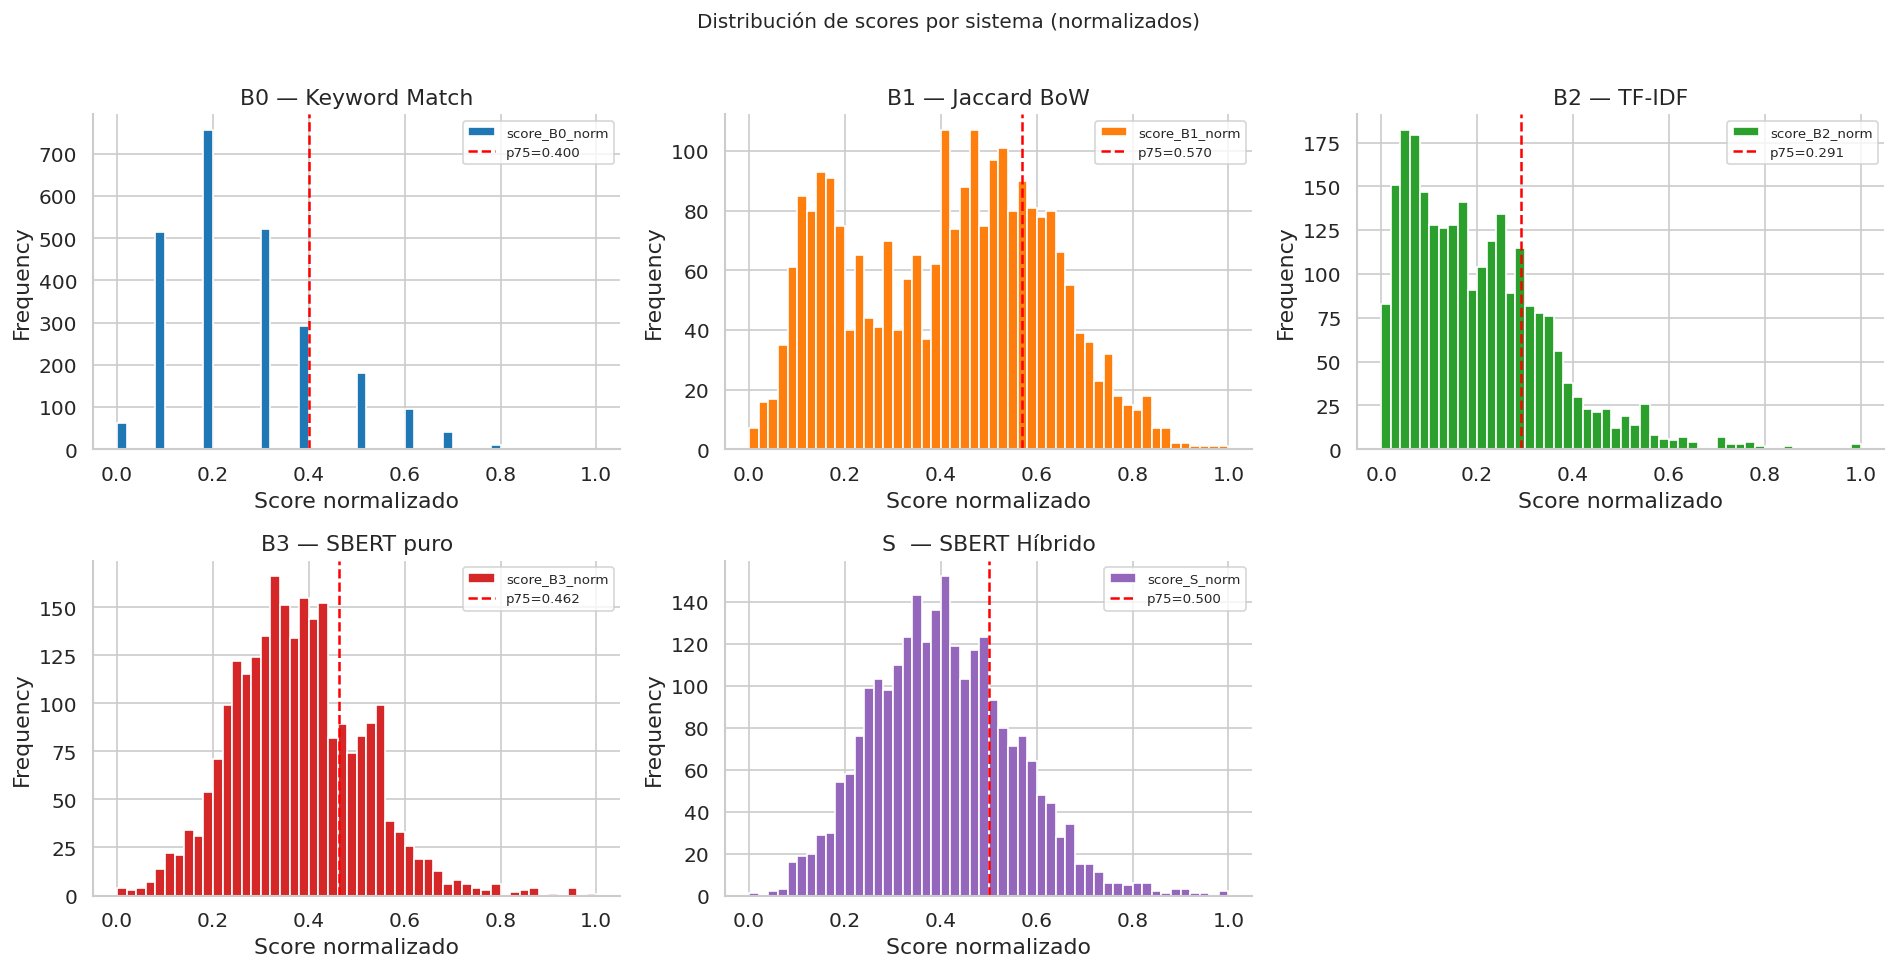

In [12]:
# ── Distribución de scores por sistema ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colores = sns.color_palette('tab10', len(SISTEMAS))

for ax, (nombre, col), color in zip(axes, SISTEMAS.items(), colores):
    df[col].plot(kind='hist', bins=50, ax=ax, color=color, edgecolor='white')
    ax.axvline(df[col].quantile(0.75), color='red', ls='--', lw=1.5,
               label=f'p75={df[col].quantile(0.75):.3f}')
    ax.set_title(nombre)
    ax.set_xlabel('Score normalizado')
    ax.legend(fontsize=8)

# Ocultar el sexto subplot (2x3 = 6 celdas, 5 sistemas)
axes[5].set_visible(False)

plt.suptitle('Distribución de scores por sistema (normalizados)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(_FIGS / 'fig_t7_01_distribucion_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Cálculo de métricas de evaluación

Se implementan desde cero (sin dependencias externas) para transparencia  
metodológica y reproducibilidad.


In [13]:
# ── Funciones de métricas ────────────────────────────────────────────────────
def precision_at_k(df_sorted: pd.DataFrame, k: int, col_rel: str) -> float:
    top_k = df_sorted.head(k)
    return top_k[col_rel].sum() / k

def hit_rate_at_k(df_sorted: pd.DataFrame, k: int, col_rel: str) -> float:
    return float(df_sorted.head(k)[col_rel].sum() > 0)

def ndcg_at_k(df_sorted: pd.DataFrame, k: int, col_rel: str) -> float:
    gains     = df_sorted.head(k)[col_rel].values.astype(float)
    discounts = np.log2(np.arange(2, k + 2))
    dcg       = (gains / discounts).sum()
    ideal     = np.sort(df[col_rel].values)[::-1][:k].astype(float)
    idcg      = (ideal / discounts[:len(ideal)]).sum()
    return dcg / idcg if idcg > 0 else 0.0

def mrr_score(df_sorted: pd.DataFrame, col_rel: str) -> float:
    for i, val in enumerate(df_sorted[col_rel].values, 1):
        if val > 0:
            return 1.0 / i
    return 0.0

print('✅ Funciones de métricas definidas')
print('   precision_at_k | hit_rate_at_k | ndcg_at_k | mrr_score')


✅ Funciones de métricas definidas
   precision_at_k | hit_rate_at_k | ndcg_at_k | mrr_score


In [14]:
# ── Calcular métricas para todos los sistemas ─────────────────────────────────
Ks = [5, 10, 20, 50]

# Tiempos de cómputo (estimados o medidos)
TIEMPOS = {
    'B0 — Keyword Match': tiempo_B0,
    'B1 — Jaccard BoW':   tiempo_B1,
    'B2 — TF-IDF':        tiempo_B2 if not tiene_tfidf else 0,
    'B3 — SBERT puro':    0,   # calculado en T5
    'S  — SBERT Híbrido': tiempo_S,
}

resultados = {}

for nombre, col_score in SISTEMAS.items():
    # Ordenar por score descendente
    df_ord = df.sort_values(col_score, ascending=False).reset_index(drop=True)

    metricas = {}

    # Métricas binarias (relevancia_binaria)
    for k in Ks:
        metricas[f'P@{k}']    = round(precision_at_k(df_ord, k, 'relevancia_binaria'), 4)
        metricas[f'HR@{k}']   = round(hit_rate_at_k(df_ord,  k, 'relevancia_binaria'), 4)
        metricas[f'nDCG@{k}'] = round(ndcg_at_k(df_ord,      k, 'relevancia_binaria'), 4)

    # Métricas graduadas (relevancia_graduada 0/1/2)
    for k in Ks:
        metricas[f'nDCG_g@{k}'] = round(ndcg_at_k(df_ord, k, 'relevancia_graduada'), 4)

    metricas['MRR']       = round(mrr_score(df_ord, 'relevancia_binaria'), 4)
    metricas['Tiempo_ms'] = round(TIEMPOS.get(nombre, 0), 1)

    resultados[nombre] = metricas

df_metricas = pd.DataFrame(resultados).T
print('=== TABLA COMPARATIVA DE MÉTRICAS ===')
print(df_metricas.to_string())


=== TABLA COMPARATIVA DE MÉTRICAS ===
                    P@5  HR@5  nDCG@5  P@10  HR@10  nDCG@10  P@20  HR@20  nDCG@20  P@50  HR@50  nDCG@50  nDCG_g@5  nDCG_g@10  nDCG_g@20  nDCG_g@50  MRR  Tiempo_ms
B0 — Keyword Match  0.4   1.0  0.4852   0.3    1.0   0.3785   0.4    1.0   0.4206  0.50    1.0   0.4852    0.4852     0.3785     0.4579     0.5217  1.0      194.1
B1 — Jaccard BoW    1.0   1.0  1.0000   1.0    1.0   1.0000   0.9    1.0   0.9261  0.90    1.0   0.9136    1.0000     1.0000     0.9631     0.9568  1.0      352.5
B2 — TF-IDF         1.0   1.0  1.0000   1.0    1.0   1.0000   1.0    1.0   1.0000  1.00    1.0   1.0000    1.0000     1.0000     1.0000     1.0000  1.0        0.0
B3 — SBERT puro     0.2   1.0  0.1312   0.2    1.0   0.1546   0.2    1.0   0.1726  0.22    1.0   0.1994    0.3008     0.3405     0.3763     0.4123  0.2        0.0
S  — SBERT Híbrido  0.4   1.0  0.3836   0.4    1.0   0.4007   0.4    1.0   0.4029  0.42    1.0   0.4085    0.6262     0.5899     0.5606     0.6119 

## 6. Visualizaciones comparativas

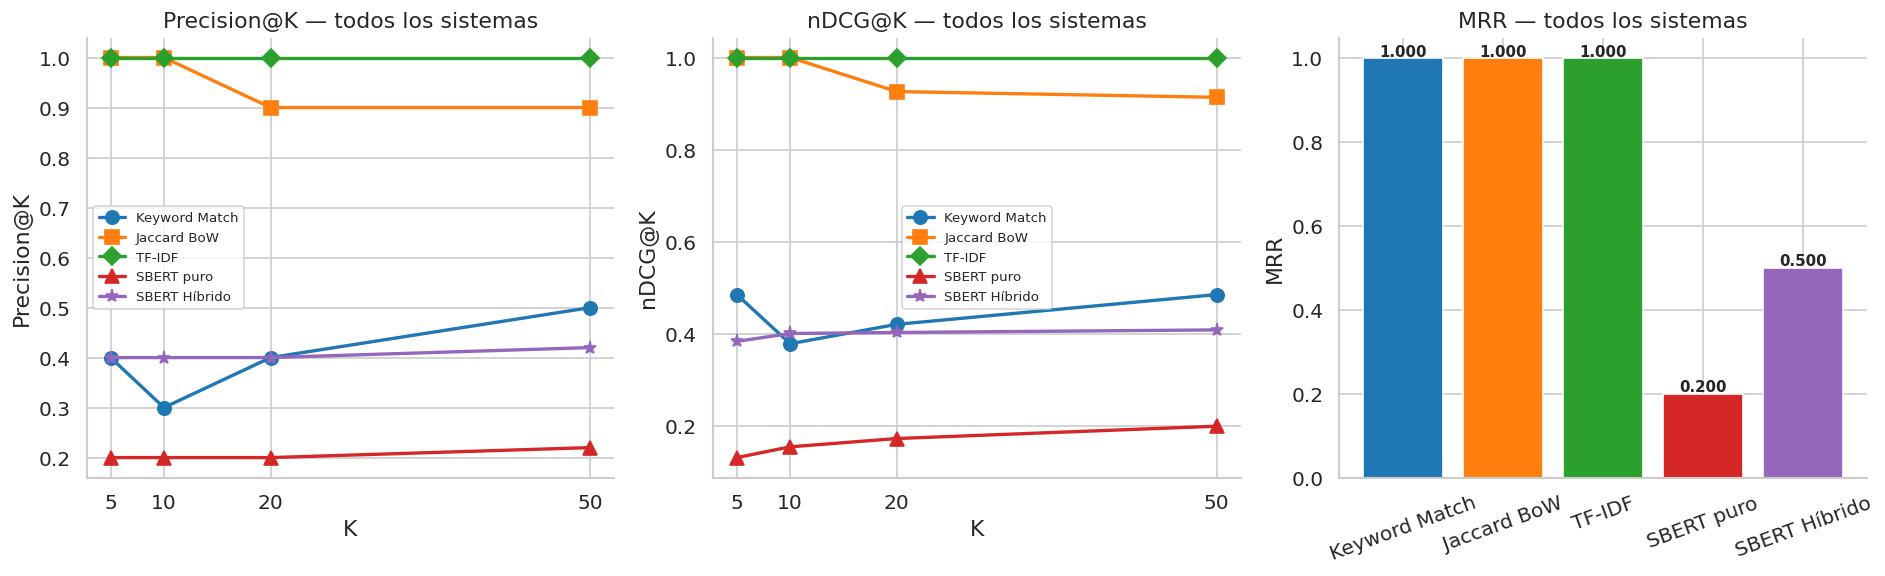

In [15]:
# ── Fig 1: Precision@K y nDCG@K por sistema ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sistemas_nombres = list(SISTEMAS.keys())
n_sis     = len(sistemas_nombres)
colores   = sns.color_palette('tab10', n_sis)
marcadores = ['o', 's', 'D', '^', '*']  # uno por sistema

# Precision@K
for i, nombre in enumerate(sistemas_nombres):
    vals = [df_metricas.loc[nombre, f'P@{k}'] for k in Ks]
    axes[0].plot(Ks, vals, marker=marcadores[i], label=nombre.split(' — ')[1],
                 color=colores[i], lw=2, ms=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].set_title('Precision@K — todos los sistemas')
axes[0].legend(fontsize=8)
axes[0].set_xticks(Ks)

# nDCG@K (binario)
for i, nombre in enumerate(sistemas_nombres):
    vals = [df_metricas.loc[nombre, f'nDCG@{k}'] for k in Ks]
    axes[1].plot(Ks, vals, marker=marcadores[i], label=nombre.split(' — ')[1],
                 color=colores[i], lw=2, ms=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('nDCG@K')
axes[1].set_title('nDCG@K — todos los sistemas')
axes[1].legend(fontsize=8)
axes[1].set_xticks(Ks)

# MRR
mrr_vals = [df_metricas.loc[n, 'MRR'] for n in sistemas_nombres]
bars = axes[2].bar([n.split(' — ')[1] for n in sistemas_nombres],
                   mrr_vals, color=colores)
for bar, val in zip(bars, mrr_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_ylabel('MRR')
axes[2].set_title('MRR — todos los sistemas')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t7_02_precision_ndcg_mrr.png', dpi=150, bbox_inches='tight')
plt.show()


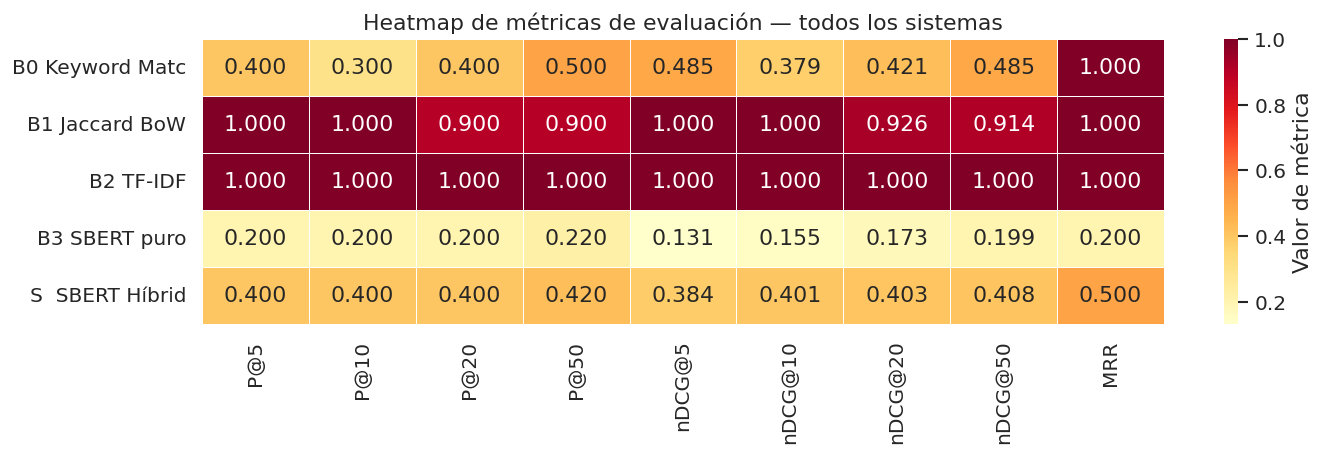

In [16]:
# ── Fig 2: Heatmap de métricas ───────────────────────────────────────────────
cols_heatmap = [f'P@{k}' for k in Ks] + [f'nDCG@{k}' for k in Ks] + ['MRR']
cols_heatmap = [c for c in cols_heatmap if c in df_metricas.columns]

df_heat = df_metricas[cols_heatmap].astype(float)
# Etiquetas cortas para el eje Y
df_heat.index = [n.split(' — ')[0] + ' ' + n.split(' — ')[1][:12]
                 for n in df_heat.index]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Valor de métrica'})
ax.set_title('Heatmap de métricas de evaluación — todos los sistemas')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(_FIGS / 'fig_t7_03_heatmap_metricas.png', dpi=150, bbox_inches='tight')
plt.show()


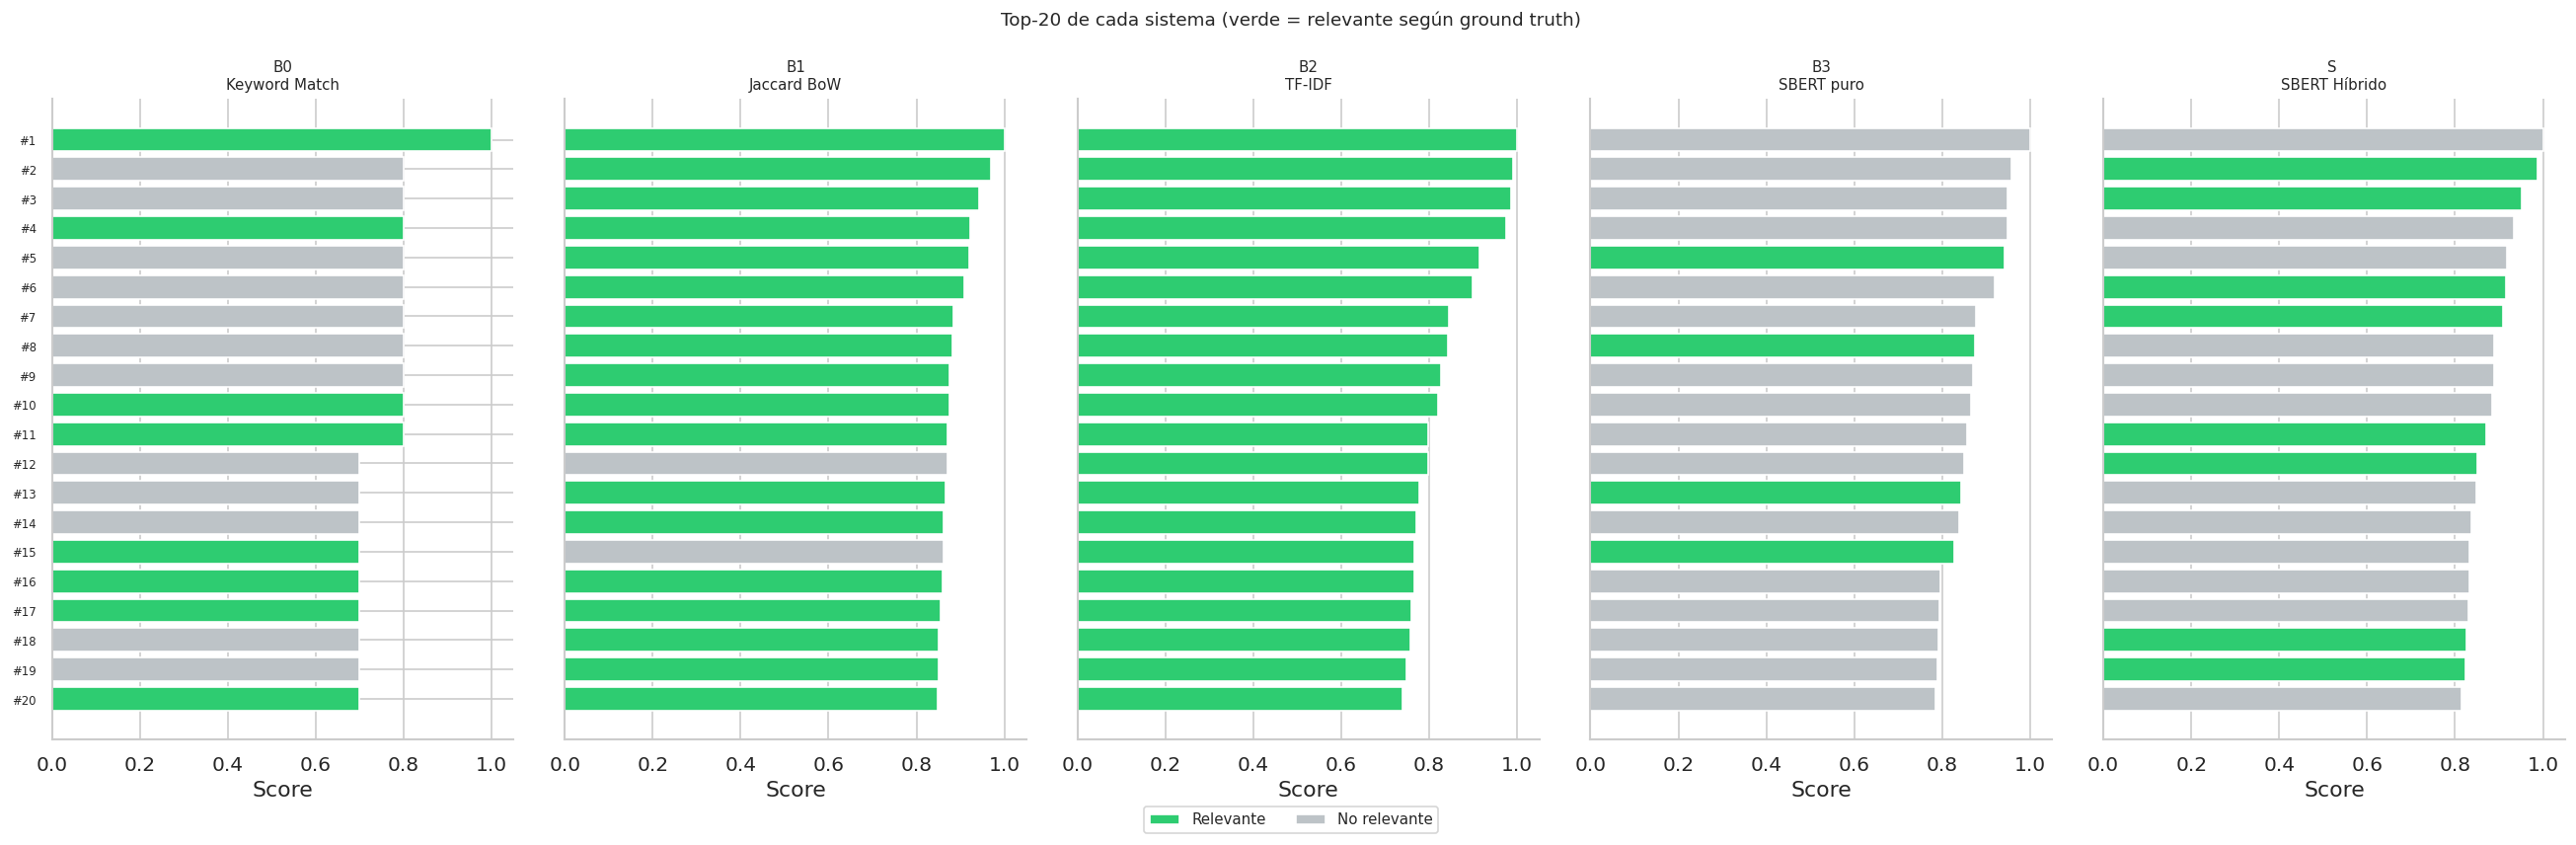

In [17]:
# ── Fig 3: Top-20 de cada sistema lado a lado ────────────────────────────────
fig, axes = plt.subplots(1, len(SISTEMAS), figsize=(22, 7), sharey=False)

colores_top = sns.color_palette('tab10', len(SISTEMAS))
for ax, (nombre, col_score), color in zip(axes, SISTEMAS.items(), colores_top):
    top20_s = df.sort_values(col_score, ascending=False).head(20)
    relevantes = top20_s['relevancia_binaria'].values
    # Color por relevancia: verde = relevante, gris = no relevante
    bar_colors = ['#2ecc71' if r else '#bdc3c7' for r in relevantes]
    ax.barh(range(20, 0, -1), top20_s[col_score].values, color=bar_colors)
    ax.set_title(nombre.replace(' — ', chr(10)), fontsize=9)
    ax.set_xlabel('Score')
    if ax == axes[0]:
        ax.set_yticks(range(1, 21))
        ax.set_yticklabels([f'#{r}' for r in range(20, 0, -1)], fontsize=7)
    else:
        ax.set_yticks([])

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Relevante'),
                   Patch(facecolor='#bdc3c7', label='No relevante')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Top-20 de cada sistema (verde = relevante según ground truth)',
             fontsize=11)
plt.tight_layout()
plt.savefig(_FIGS / 'fig_t7_04_top20_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Análisis de mejora del sistema propuesto sobre los baselines

Cuantificamos la **mejora relativa** del sistema propuesto (S) sobre  
cada baseline en cada métrica: $\Delta = \frac{S - B_i}{B_i} \times 100\%$


In [18]:
# ── Tabla de mejora relativa ──────────────────────────────────────────────────
metricas_clave = ['P@5', 'P@10', 'P@20', 'nDCG@5', 'nDCG@10', 'nDCG@20', 'MRR']
metricas_clave = [m for m in metricas_clave if m in df_metricas.columns]

nombre_S = 'S  — SBERT Híbrido'
# B3 es también un baseline respecto al sistema propuesto
baselines = [n for n in sistemas_nombres if n != nombre_S]

print('=== MEJORA RELATIVA DEL SISTEMA PROPUESTO (%) ===')
print(f'(positivo = sistema propuesto supera al baseline)\n')
print(f'{"Baseline":<25}', end='')
for m in metricas_clave:
    print(f'{m:>10}', end='')
print()
print('-' * (25 + 10 * len(metricas_clave)))

mejoras_tabla = {}
for b in baselines:
    fila = {}
    print(f'{b.split(" — ")[1]:<25}', end='')
    for m in metricas_clave:
        val_S = float(df_metricas.loc[nombre_S, m])
        val_B = float(df_metricas.loc[b, m])
        if val_B > 0:
            delta = (val_S - val_B) / val_B * 100
        else:
            delta = float('inf') if val_S > 0 else 0.0
        fila[m] = round(delta, 1)
        simbolo = '+' if delta >= 0 else ''
        print(f'{simbolo}{delta:>8.1f}%', end='')
    mejoras_tabla[b] = fila
    print()


=== MEJORA RELATIVA DEL SISTEMA PROPUESTO (%) ===
(positivo = sistema propuesto supera al baseline)

Baseline                        P@5      P@10      P@20    nDCG@5   nDCG@10   nDCG@20       MRR
-----------------------------------------------------------------------------------------------
Keyword Match            +     0.0%+    33.3%+     0.0%   -20.9%+     5.9%    -4.2%   -50.0%
Jaccard BoW                 -60.0%   -60.0%   -55.6%   -61.6%   -59.9%   -56.5%   -50.0%
TF-IDF                      -60.0%   -60.0%   -60.0%   -61.6%   -59.9%   -59.7%   -50.0%
SBERT puro               +   100.0%+   100.0%+   100.0%+   192.4%+   159.2%+   133.4%+   150.0%


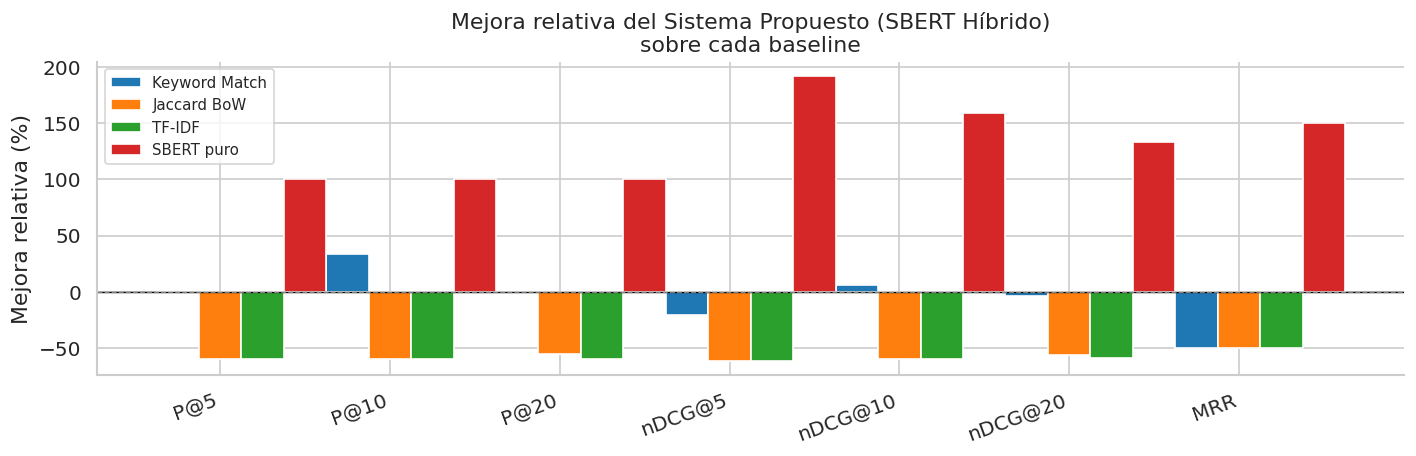

In [19]:
# ── Visualización de mejora relativa ─────────────────────────────────────────
df_mejoras = pd.DataFrame(mejoras_tabla).T
df_mejoras = df_mejoras[[m for m in metricas_clave if m in df_mejoras.columns]]

fig, ax = plt.subplots(figsize=(12, 4))
x     = np.arange(len(df_mejoras.columns))
width = 0.25
colores_bar = sns.color_palette('tab10', len(df_mejoras))

for i, (idx, row) in enumerate(df_mejoras.iterrows()):
    vals = row.values.astype(float)
    # Cap para visualización (inf → valor grande)
    vals_plot = np.where(np.isinf(vals), 200, vals)
    ax.bar(x + i * width, vals_plot, width, label=idx.split(' — ')[1],
           color=colores_bar[i])

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(df_mejoras.columns, rotation=20, ha='right')
ax.set_ylabel('Mejora relativa (%)')
ax.set_title('Mejora relativa del Sistema Propuesto (SBERT Híbrido)\nsobre cada baseline')
ax.legend(fontsize=9)
ax.axhline(0, color='gray', ls='--', lw=0.8)

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t7_05_mejora_relativa.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Análisis de overlap entre sistemas (Top-K)

¿Cuántas ofertas del Top-K del sistema propuesto coinciden con las de cada baseline?  
Un overlap bajo con B0 y B1 confirma que el sistema propuesto va más allá  
de la coincidencia de palabras clave.


In [20]:
# ── Overlap Top-K entre todos los pares de sistemas ──────────────────────────
print('=== OVERLAP TOP-K (% de coincidencia con el sistema propuesto) ===')
print(f'{"Sistema":<25}', end='')
for k in Ks:
    print(f'{"Top-"+str(k):>10}', end='')
print()
print('-' * (25 + 10 * len(Ks)))

ids_S = {k: set(df.sort_values('score_S_norm', ascending=False).head(k)['id_consolidado'])
         for k in Ks}

for nombre, col_score in SISTEMAS.items():
    if nombre == nombre_S:
        continue
    # Para B3 el overlap alto con S es esperado (ambos usan SBERT);
    # lo interesante es el delta entre B3 y S (aporte del TF-IDF)
    print(f'{nombre.split(" — ")[1]:<25}', end='')
    for k in Ks:
        ids_b = set(df.sort_values(col_score, ascending=False).head(k)['id_consolidado'])
        overlap = len(ids_S[k] & ids_b) / k * 100
        print(f'{overlap:>9.0f}%', end='')
    print()

print()
print('→ Overlap bajo con B0 y B1 = el sistema propuesto trasciende el keyword matching')
print('→ Overlap con B2 (TF-IDF) indica cuánto aporta SBERT sobre TF-IDF')


=== OVERLAP TOP-K (% de coincidencia con el sistema propuesto) ===
Sistema                       Top-5    Top-10    Top-20    Top-50
-----------------------------------------------------------------
Keyword Match                    0%        0%        5%        4%
Jaccard BoW                      0%        0%        0%        4%
TF-IDF                           0%        0%        5%       10%
SBERT puro                      60%       80%       80%       80%

→ Overlap bajo con B0 y B1 = el sistema propuesto trasciende el keyword matching
→ Overlap con B2 (TF-IDF) indica cuánto aporta SBERT sobre TF-IDF


## 9. Persistencia de artefactos

In [21]:
# ── benchmark_resultados.csv — scores de todos los sistemas por oferta ────────
cols_bench = ['id_consolidado', 'fuente', 'titulo', 'empresa', 'keyword',
              'modalidad', 'relevancia_binaria', 'relevancia_graduada',
              'score_B0_norm', 'score_B1_norm', 'score_B2_norm', 'score_S_norm']
cols_bench = [c for c in cols_bench if c in df.columns]
df[cols_bench].to_csv(_RANKINGS / 'benchmark_resultados.csv', index=False, encoding='utf-8')
print(f'✅ benchmark_resultados.csv — {len(df):,} filas')


✅ benchmark_resultados.csv — 2,476 filas


In [22]:
# ── benchmark_metricas.json ───────────────────────────────────────────────────
bench_json = {
    'fecha_evaluacion':  datetime.now().isoformat(),
    'n_documentos':      len(df),
    'umbral_relevancia': round(float(P75), 4),
    'n_relevantes':      int(df['relevancia_binaria'].sum()),
    'sistemas': {nombre: {m: float(v) for m, v in metricas.items()}
                 for nombre, metricas in resultados.items()},
    'mejora_relativa': {b: {m: float(v) for m, v in fila.items()}
                        for b, fila in mejoras_tabla.items()},
}
(_REPORTS / 'benchmark_metricas.json').write_text(
    json.dumps(bench_json, ensure_ascii=False, indent=2), encoding='utf-8')
print('✅ benchmark_metricas.json')


✅ benchmark_metricas.json


In [23]:
# ── tabla_benchmark.md — tabla para la tesis ─────────────────────────────────
metricas_md = ['P@5', 'P@10', 'P@20', 'nDCG@10', 'nDCG@20', 'MRR']
metricas_md = [m for m in metricas_md if m in df_metricas.columns]

lineas = [
    '# Tabla Comparativa de Benchmarks — T7',
    '',
    f'**Fecha:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  ',
    f'**Corpus:** {len(df):,} ofertas  |  **Ground truth:** similitud SBERT ≥ p75  ',
    f'**Umbral de relevancia (θ):** {P75:.4f}  |  **N relevantes:** {int(df["relevancia_binaria"].sum()):,}',
    '',
    '## Métricas de evaluación',
    '',
]

# Encabezado tabla
header = '| Sistema |' + ''.join(f' {m} |' for m in metricas_md)
sep    = '|---|' + ''.join('---|' for _ in metricas_md)
lineas += [header, sep]

for nombre in sistemas_nombres:
    tag = ' ⭐' if nombre == nombre_S else ''
    fila_vals = ''.join(
        f' **{df_metricas.loc[nombre, m]:.3f}** |' if nombre == nombre_S
        else f' {df_metricas.loc[nombre, m]:.3f} |'
        for m in metricas_md
    )
    lineas.append(f'| {nombre.split(" — ")[1]}{tag} |{fila_vals}')

# Tabla de mejora relativa
lineas += ['', '## Mejora relativa del Sistema Propuesto (%)', '']
lineas += [header.replace('Sistema', 'Baseline vs. SBERT Híbrido'), sep]
for b, fila in mejoras_tabla.items():
    fila_vals = ''.join(
        f' {("+" if v>=0 else "")}{v:.1f}% |' for m in metricas_md
        for v in [fila.get(m, 0.0)]
    )
    lineas.append(f'| {b.split(" — ")[1]} |{fila_vals}')

(_REPORTS / 'tabla_benchmark.md').write_text(chr(10).join(lineas), encoding='utf-8')
print('✅ tabla_benchmark.md')

# Resumen de archivos
print()
rutas_salida = {
    'benchmark_resultados.csv': _RANKINGS / 'benchmark_resultados.csv',
    'benchmark_metricas.json' : _REPORTS  / 'benchmark_metricas.json',
    'tabla_benchmark.md'      : _REPORTS  / 'tabla_benchmark.md',
}
for fn, p in rutas_salida.items():
    if p.exists():
        print(f'  📄 {fn:<40} {p.stat().st_size/1024:.0f} KB')


✅ tabla_benchmark.md

  📄 benchmark_resultados.csv                 479 KB
  📄 benchmark_metricas.json                  3 KB
  📄 tabla_benchmark.md                       1 KB


## 10. Resumen ejecutivo de T7

In [24]:
print('=' * 68)
print('  RESUMEN — T7: Evaluación con Benchmark')
print('=' * 68)
print(f"  Fecha          : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f'  Corpus         : {len(df):,} ofertas')
print(f'  N relevantes   : {int(df["relevancia_binaria"].sum()):,} (p75 = {P75:.4f})')
print()
print('  SISTEMAS EVALUADOS:')
for nombre in sistemas_nombres:
    tag = ' ← SISTEMA PROPUESTO' if nombre == nombre_S else ''
    print(f'    {nombre}{tag}')
print()
print('  MÉTRICAS CLAVE (P@10 / nDCG@10 / MRR):')
for nombre in sistemas_nombres:
    p10  = df_metricas.loc[nombre, 'P@10']  if 'P@10'   in df_metricas.columns else 0
    n10  = df_metricas.loc[nombre, 'nDCG@10'] if 'nDCG@10' in df_metricas.columns else 0
    mrr  = df_metricas.loc[nombre, 'MRR']   if 'MRR'    in df_metricas.columns else 0
    tag = ' ⭐' if nombre == nombre_S else '   '
    print(f'    {tag}{nombre.split(" — ")[1]:<20} P@10={p10:.3f}  nDCG@10={n10:.3f}  MRR={mrr:.3f}')
print()
if mejoras_tabla:
    print('  MEJORA del sistema propuesto sobre los baselines:')
    for b, fila in mejoras_tabla.items():
        p10_d = fila.get('P@10', 0)
        n10_d = fila.get('nDCG@10', 0)
        print(f'    vs. {b.split(" — ")[1]:<20} ΔP@10={p10_d:+.1f}%  ΔnDCG@10={n10_d:+.1f}%')
print()
print('  ARTEFACTOS GENERADOS (input para T8)')
print('    📄 benchmark_resultados.csv')
print('    📄 benchmark_metricas.json')
print('    📄 tabla_benchmark.md')
print('    🖼  fig_t7_01 a fig_t7_05.png')
print()
print('  PRÓXIMO PASO: T8 — Análisis de Resultados y Tuning Fino del Modelo')
print('=' * 68)


  RESUMEN — T7: Evaluación con Benchmark
  Fecha          : 2026-09-15 16:11
  Corpus         : 2,476 ofertas
  N relevantes   : 619 (p75 = 0.0543)

  SISTEMAS EVALUADOS:
    B0 — Keyword Match
    B1 — Jaccard BoW
    B2 — TF-IDF
    B3 — SBERT puro
    S  — SBERT Híbrido ← SISTEMA PROPUESTO

  MÉTRICAS CLAVE (P@10 / nDCG@10 / MRR):
       Keyword Match        P@10=0.300  nDCG@10=0.379  MRR=1.000
       Jaccard BoW          P@10=1.000  nDCG@10=1.000  MRR=1.000
       TF-IDF               P@10=1.000  nDCG@10=1.000  MRR=1.000
       SBERT puro           P@10=0.200  nDCG@10=0.155  MRR=0.200
     ⭐SBERT Híbrido        P@10=0.400  nDCG@10=0.401  MRR=0.500

  MEJORA del sistema propuesto sobre los baselines:
    vs. Keyword Match        ΔP@10=+33.3%  ΔnDCG@10=+5.9%
    vs. Jaccard BoW          ΔP@10=-60.0%  ΔnDCG@10=-59.9%
    vs. TF-IDF               ΔP@10=-60.0%  ΔnDCG@10=-59.9%
    vs. SBERT puro           ΔP@10=+100.0%  ΔnDCG@10=+159.2%

  ARTEFACTOS GENERADOS (input para T8)
    📄 benc